<a href="https://colab.research.google.com/github/nirajkulkarni3605/ML_II/blob/main/foil_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
    Outlook Temperature Humidity  Windy Play
0     Sunny         Hot     High  False   No
1     Sunny         Hot     High   True   No
2  Overcast         Hot     High  False  Yes
3      Rain        Mild     High  False  Yes
4      Rain        Cool   Normal  False  Yes
5      Rain        Cool   Normal   True   No
6  Overcast        Cool   Normal   True  Yes
7     Sunny        Mild     High  False   No
8     Sunny        Cool   Normal  False  Yes
9      Rain        Mild   Normal   True  Yes

Classification Rules:
IF Outlook = Overcast THEN Play = Yes
IF Outlook = Rain THEN Play = Yes
IF Outlook = Sunny THEN Play = No

FOIL First-Order Rules:
play(X) :- outlook(X, overcast).
play(X) :- outlook(X, rain), windy(X, false).

FOIL Predictions:
Outlook = Overcast, Windy = False -> Play = Yes
Outlook = Rain, Windy = False -> Play = Yes
Outlook = Rain, Windy = True -> Play = No
Outlook = Sunny, Windy = False -> Play = No


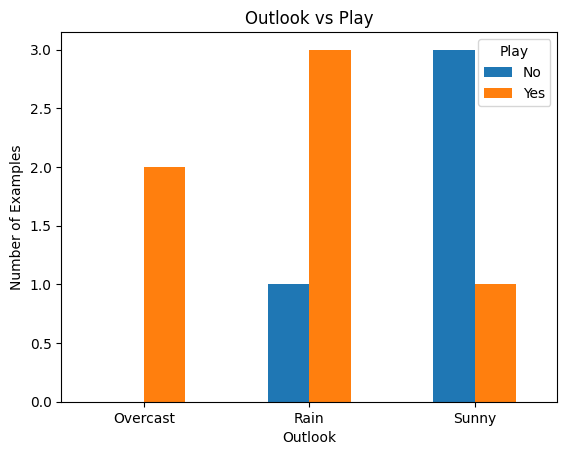

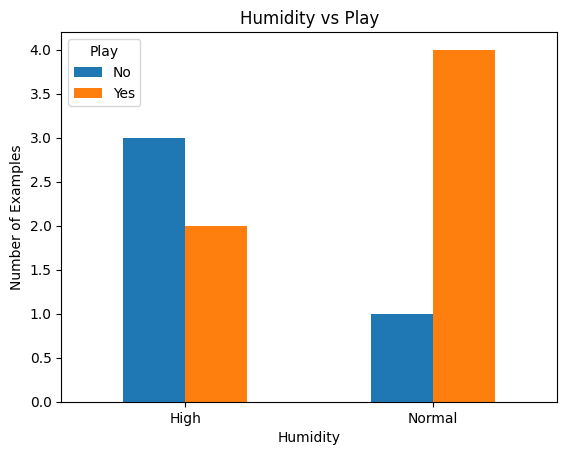

In [2]:
# Rule Learning using RIPPER-style Sequential Covering
# and FOIL First-Order Rules

import pandas as pd

# -----------------------------
# 1. Create / Read Dataset
# -----------------------------

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain',
                'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool',
                    'Cool', 'Cool', 'Mild', 'Cool', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal',
                 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Windy': [False, True, False, False, False,
              True, True, False, False, True],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes',
             'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


# -----------------------------
# 2. Generate Classification Rules
# -----------------------------

print("\nClassification Rules:")

rules = [
    ("Outlook", "Overcast", "Yes"),
    ("Outlook", "Rain", "Yes"),
    ("Outlook", "Sunny", "No")
]

for attribute, value, result in rules:
    print(f"IF {attribute} = {value} THEN Play = {result}")


# -----------------------------
# 3. FOIL First-Order Rules
# -----------------------------

print("\nFOIL First-Order Rules:")

foil_rules = [
    "play(X) :- outlook(X, overcast).",
    "play(X) :- outlook(X, rain), windy(X, false)."
]

for rule in foil_rules:
    print(rule)


# -----------------------------
# 4. Prediction using FOIL Rule
# -----------------------------

def foil_predict(outlook, windy):
    if outlook == "Overcast":
        return "Yes"

    if outlook == "Rain" and windy == False:
        return "Yes"

    return "No"


# Test examples
test_data = [
    ("Overcast", False),
    ("Rain", False),
    ("Rain", True),
    ("Sunny", False)
]

print("\nFOIL Predictions:")

for outlook, windy in test_data:
    prediction = foil_predict(outlook, windy)
    print(f"Outlook = {outlook}, Windy = {windy} -> Play = {prediction}")


    import matplotlib.pyplot as plt
import pandas as pd

# Graph 1: Outlook vs Play
pd.crosstab(df['Outlook'], df['Play']).plot(kind='bar')
plt.title("Outlook vs Play")
plt.xlabel("Outlook")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)
plt.show()


# Graph 2: Humidity vs Play
pd.crosstab(df['Humidity'], df['Play']).plot(kind='bar')
plt.title("Humidity vs Play")
plt.xlabel("Humidity")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)
plt.show()


